## XAI EEGnet

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix


from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    NoiseTunnel
)

import shap

In [17]:
class EEGNet(nn.Module):
    def __init__(self, in_channels=18, window_size=256, num_classes=1, F1=8, D=2, F2=16):
        super(EEGNet, self).__init__()
        
        self.in_channels = in_channels
        self.window_size = window_size
        
        # ==========================================
        # BLOQUE 1: Convolución Temporal
        # Extrae frecuencias de banda del EEG
        # ==========================================
        self.conv1 = nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False)
        self.batchnorm1 = nn.InstanceNorm2d(F1)
        
        # ==========================================
        # BLOQUE 2: Convolución Espacial (Depthwise)
        # Aprende qué electrodos son importantes sin mezclarlos todos a lo bruto
        # ==========================================
        self.depthwise1 = nn.Conv2d(F1, F1 * D, (in_channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.InstanceNorm2d(F1 * D)
        self.pooling1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(p=0.25)
        
        # ==========================================
        # BLOQUE 3: Convolución Separable
        # Combina la información temporal y espacial de forma súper eficiente
        # ==========================================
        self.separable_depth = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False)
        self.separable_point = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.InstanceNorm2d(F2)
        self.pooling2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(p=0.25)
        
        # ==========================================
        # CÁLCULO DINÁMICO DE LA DIMENSIÓN FINAL
        # ==========================================
        dummy = torch.zeros(1, 1, in_channels, window_size)
        with torch.no_grad():
            x = self.conv1(dummy)
            x = self.batchnorm1(x)
            x = self.depthwise1(x)
            x = self.batchnorm2(x)
            x = F.elu(x)
            x = self.pooling1(x)
            x = self.dropout1(x)
            
            x = self.separable_depth(x)
            x = self.separable_point(x)
            x = self.batchnorm3(x)
            x = F.elu(x)
            x = self.pooling2(x)
            x = self.dropout2(x)
            self.final_dim = x.numel()
            
        # Clasificador final
        self.fc = nn.Linear(self.final_dim, num_classes)

    def forward(self, x):
        # x entra como (Batch, in_channels, window_size). EEGNet necesita (Batch, 1, in_channels, window_size)
        x = x.unsqueeze(1)
        
        # Bloque 1
        x = self.conv1(x)
        x = self.batchnorm1(x)
        
        # Bloque 2
        x = self.depthwise1(x)
        x = self.batchnorm2(x)
        x = F.elu(x)
        x = self.pooling1(x)
        x = self.dropout1(x)
        
        # Bloque 3
        x = self.separable_depth(x)
        x = self.separable_point(x)
        x = self.batchnorm3(x)
        x = F.elu(x)
        x = self.pooling2(x)
        x = self.dropout2(x)
        
        # Flatten y Clasificación
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [18]:
class EEGDataset(Dataset):
    def __init__(self, root_dir, sets=None):
        self.root_dir = root_dir

        if sets is None:
            sets = ['set_A','set_B','set_C','set_D','set_E']

        self.samples = []
        self.labels = []
        self.label_map = {s: i for i, s in enumerate(sets)}

        for set_name in sets:
            folder = os.path.join(root_dir, set_name)

            for file in sorted(os.listdir(folder)):
                if file.endswith('.txt'):
                    self.samples.append(os.path.join(folder, file))
                    self.labels.append(self.label_map[set_name])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]

        signal = np.loadtxt(path)

        # convertir a tensor
        signal = torch.tensor(signal, dtype=torch.float32)

        # asegurar formato (canal=1, tiempo)
        signal = signal.unsqueeze(0)

        # normalización
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return signal, label

In [19]:
class EEGTransforms:
    def __init__(self, noise_std_range=(0.01, 0.05), scale_range=(0.8, 1.2)):
        self.noise_min, self.noise_max = noise_std_range
        self.scale_min, self.scale_max = scale_range

    def __call__(self, signal):
        scale_factor = torch.empty(1).uniform_(self.scale_min, self.scale_max).item()
        signal = signal * scale_factor
        std = torch.empty(1).uniform_(self.noise_min, self.noise_max).item()
        noise = torch.randn_like(signal) * std
        return signal + noise


class SeizureDatasetMultichannel(Dataset):
    def __init__(
        self,
        signals_path,
        labels_path,
        indices=None,
        augment=False,
        sequence_length=1,
        num_samples=1352243
    ):
        self.signals_path = signals_path
        self.labels_path = labels_path
        self.indices = np.asarray(indices) if indices is not None else np.arange(num_samples)

        self.augment = augment
        self.sequence_length = sequence_length
        self.transforms = EEGTransforms() if self.augment else None

        self.num_samples = num_samples
        self.signals = None
        self.labels = None

    def __len__(self):
        return len(self.indices)

    def _lazy_init(self):
        if self.signals is None:
            self.signals = np.memmap(
                self.signals_path,
                dtype='float32',
                mode='r',
                shape=(self.num_samples, 18, 256)
            )
            self.labels = np.memmap(
                self.labels_path,
                dtype='float32',
                mode='r',
                shape=(self.num_samples,)
            )

    def __getitem__(self, idx):
        self._lazy_init()

        real_idx = int(self.indices[idx])

        if self.sequence_length == 1:
            signal = self.signals[real_idx]
            label = self.labels[real_idx]
        else:
            start_idx = max(0, real_idx - self.sequence_length + 1)
            signal_seq = self.signals[start_idx:real_idx + 1]

            pad_len = self.sequence_length - len(signal_seq)
            if pad_len > 0:
                pad = np.repeat(signal_seq[0:1], pad_len, axis=0)
                signal_seq = np.concatenate([pad, signal_seq], axis=0)

            signal = signal_seq
            label = self.labels[real_idx]

        signal = torch.tensor(np.copy(signal), dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)

        if self.sequence_length == 1:
            mean = signal.mean(dim=1, keepdim=True)
            std = signal.std(dim=1, keepdim=True)
        else:
            mean = signal.mean(dim=(0, 2), keepdim=True)
            std = signal.std(dim=(0, 2), keepdim=True)

        signal = (signal - mean) / (std + 1e-6)

        if self.augment and self.transforms:
            signal = self.transforms(signal)

        return signal, label

In [20]:
# Adaptamos la carga para usar los datos CHBMIT procesados (memmap)
processed_dir = os.path.join('..', 'data', 'CHBMIT', 'processed', 'ventana1s')
signals_path = os.path.join(processed_dir, 'chbmit_signals.bin')
labels_path = os.path.join(processed_dir, 'chbmit_labels.bin')

# Calculamos el número de muestras a partir del tamaño del fichero (float32)
# formato esperado: (num_samples, 18, 256)
try:
    sig_size = os.path.getsize(signals_path)
    num_samples = sig_size // (18 * 256 * 4)
except Exception as e:
    print('No se pudo obtener num_samples automáticamente:', e)
    num_samples = None

dataset = SeizureDatasetMultichannel(signals_path, labels_path, num_samples=num_samples)

print("Total muestras:", len(dataset))

Total muestras: 2090076


In [21]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CHBMIT procesado: 18 canales, ventanas de 256 samples
model = EEGNet(in_channels=18, window_size=256, num_classes=1).to(device)

try:
    checkpoint = torch.load("../models/eegnet_clinical_best_def.pth", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Checkpoint cargado correctamente")
except RuntimeError as e:
    print("No se pudo cargar el checkpoint por incompatibilidad de arquitectura:", e)
    print("Usando modelo inicializado sin pesos preentrenados.")

model.eval()


Checkpoint cargado correctamente


EEGNet(
  (conv1): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
  (batchnorm1): InstanceNorm2d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (depthwise1): Conv2d(8, 16, kernel_size=(18, 1), stride=(1, 1), groups=8, bias=False)
  (batchnorm2): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (pooling1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (dropout1): Dropout(p=0.25, inplace=False)
  (separable_depth): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
  (separable_point): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (batchnorm3): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (pooling2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [23]:
def predict(model, loader):
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            #preds = torch.argmax(out, dim=1).cpu().numpy()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).int().cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(y.numpy())

    return np.array(preds_all), np.array(labels_all)

c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    417199
         1.0       0.00      0.00      0.00       817

    accuracy                           1.00    418016
   macro avg       0.50      0.50      0.50    418016
weighted avg       1.00      1.00      1.00    418016



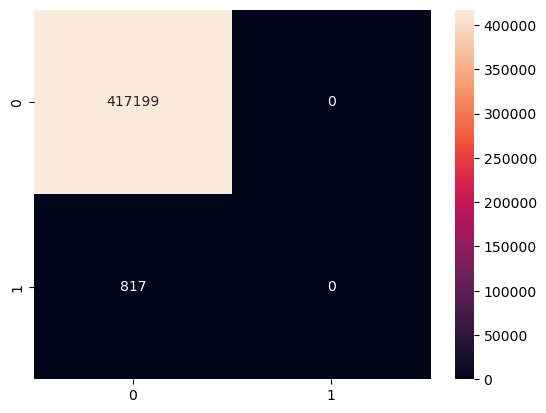

In [24]:
preds, labels = predict(model, test_loader)

print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

<Figure size 1700x400 with 0 Axes>

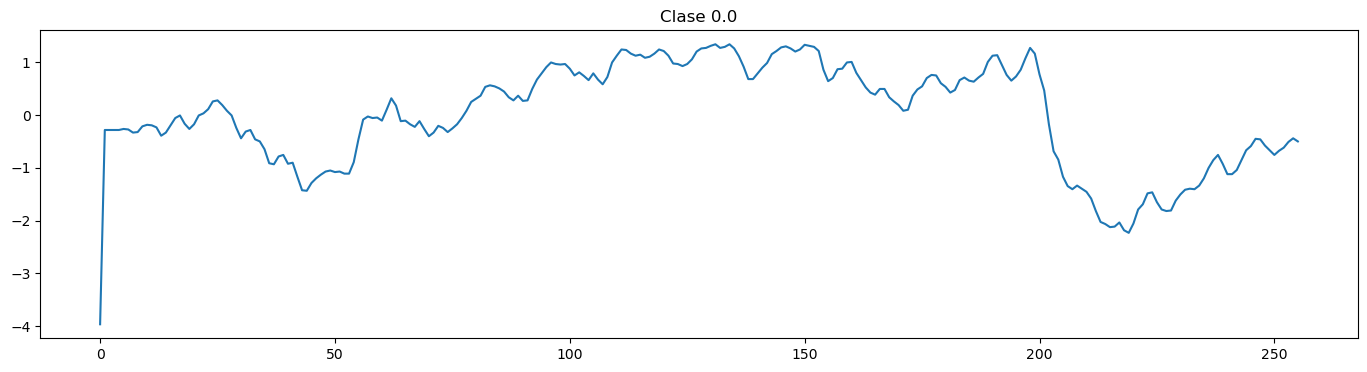

In [29]:
x, y = dataset[0]
x_input = x.unsqueeze(0).to(device)

plt.figure(figsize=(17, 4))
# Mostrar únicamente el primer canal para evitar solapamiento de 18 canales
sig = x.squeeze().numpy()
if sig.ndim > 1:
    sig_to_plot = sig[0]  # primer canal
else:
    sig_to_plot = sig

plt.figure(figsize=(17, 4))
plt.plot(sig_to_plot)
plt.title(f"Clase {y}")
plt.show()

In [30]:
# Obtenemos un lote de datos para las pruebas de XAI
dataiter = iter(test_loader)
signals, labels = next(dataiter)
signals = signals.to(device)

# Seleccionamos una muestra específica (por ejemplo, la primera del lote)
sample_idx = 0
input_signal = signals[sample_idx:sample_idx+1] # Conservar dimensión de batch [1, 1, seq_len]

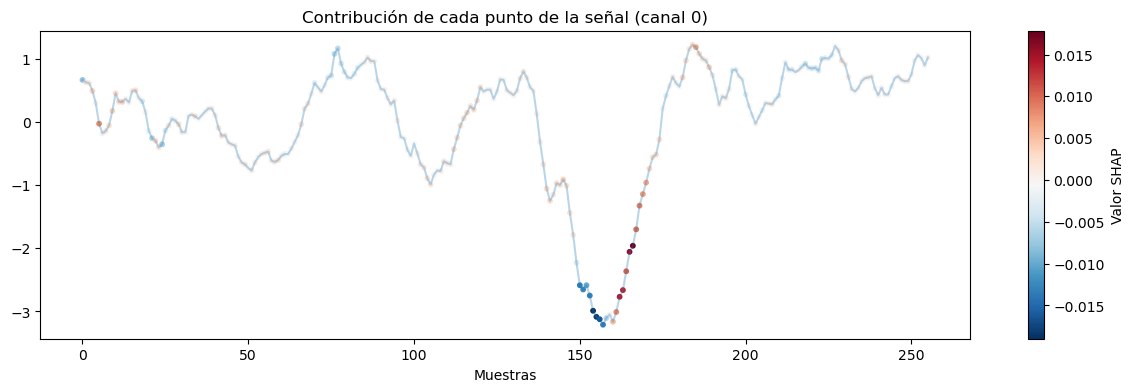

In [31]:
import shap

# 1. Asegúrate de que el modelo esté en modo evaluación
model.eval()

# 2. Preparar datos de fondo (background) y prueba
# Tomamos un lote del loader
batch_signals, _ = next(iter(train_loader))
background = batch_signals[:10].to(device)
test_sample = signals[0:1].to(device)  # Una sola muestra para explicar

# 3. Inicializar GradientExplainer en lugar de DeepExplainer
# GradientExplainer tiene mejor compatibilidad con operaciones PyTorch modernas
explainer = shap.GradientExplainer(model, background)

# 4. Calcular valores SHAP
shap_values = explainer.shap_values(test_sample)

# 5. Visualización (usar sólo el primer canal para claridad)
sv = shap_values[0] if isinstance(shap_values, list) else shap_values
sv = np.asarray(sv).squeeze()
# Obtener valores SHAP para el primer canal si es multicanal
if sv.ndim == 2:
    shap_first = sv[0]
else:
    shap_first = sv

# Señal de prueba: primer canal
arr = test_sample.cpu().numpy().squeeze()
if arr.ndim > 1:
    sig_first = arr[0]
else:
    sig_first = arr

plt.figure(figsize=(15, 4))
plt.plot(sig_first, label='Señal EEG (canal 0)', alpha=0.3)
plt.scatter(range(len(shap_first)), sig_first, c=shap_first, cmap='RdBu_r', s=10)
plt.colorbar(label='Valor SHAP')
plt.title("Contribución de cada punto de la señal (canal 0)")
plt.xlabel('Muestras')
plt.show()

C:\Users\naidl\AppData\Local\Temp\ipykernel_31960\217416085.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()


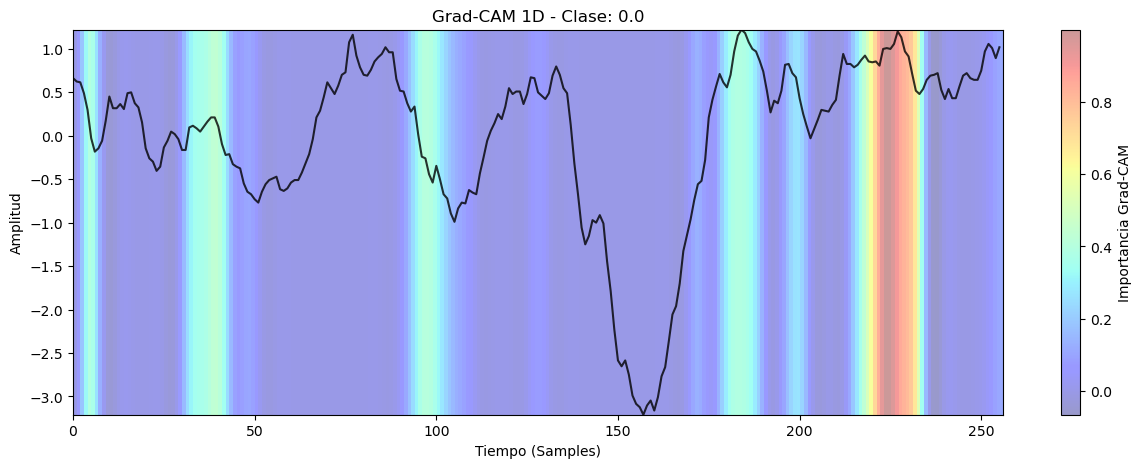

In [32]:
import torch.nn.functional as F

class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Registramos los hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor):
        # Asegurar modo eval pero con gradientes habilitados
        self.model.eval()
        
        # Paso hacia adelante
        output = self.model(input_tensor) # Forma: [1, 1]
        
        # Paso hacia atrás (backward)
        self.model.zero_grad()
        output.backward()

        # 1. Pesos: Promedio de los gradientes por canal (Global Average Pooling de gradientes)
        # self.gradients tiene forma: [Batch*Canales_EEG, Filtros, Longitud_Temporal]
        weights = torch.mean(self.gradients, dim=2, keepdim=True)

        # 2. Mapa de activación: Combinación lineal de activaciones y pesos
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # 3. ReLU: Nos interesan solo las características que influyen positivamente
        cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()
        
        # 4. Normalización
        if np.max(cam) != np.min(cam):
            cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))
            
        return cam

# --- EJECUCIÓN ---

# 1. Seleccionamos la capa: Usaremos la última capa convolucional del Bloque 3
# En tu estructura es el primer elemento de la secuencia block3
target_layer = model.separable_depth

# 2. Instanciamos y generamos
gcam = GradCAM1D(model, target_layer)

# Tomamos una muestra de test (asegúrate de que tenga forma [1, Num_Canales, Tiempo])
sample_signal, sample_label = next(iter(test_loader))
sample_input = sample_signal[0:1].to(device)

mask = gcam.generate(sample_input)

# 3. Visualización
from scipy.ndimage import zoom

plt.figure(figsize=(15, 5))
signal_plot = sample_input.cpu().squeeze().numpy()

# Seleccionar primer canal si es multicanal
if signal_plot.ndim > 1:
    sig_plot = signal_plot[0]
else:
    sig_plot = signal_plot

# Ajustamos la máscara Grad-CAM al tamaño del primer canal
mask_resized = zoom(mask, len(sig_plot) / len(mask))

# Dibujamos la señal (primer canal)
plt.plot(sig_plot, color='black', alpha=0.8)

# Superponemos el mapa de calor
plt.imshow(mask_resized[np.newaxis, :], aspect='auto', cmap='jet', alpha=0.4, 
           extent=[0, len(sig_plot), np.min(sig_plot), np.max(sig_plot)])

plt.colorbar(label='Importancia Grad-CAM')
plt.title(f'Grad-CAM 1D - Clase: {sample_label[0].item()}')
plt.xlabel('Tiempo (Samples)')
plt.ylabel('Amplitud')
plt.show()

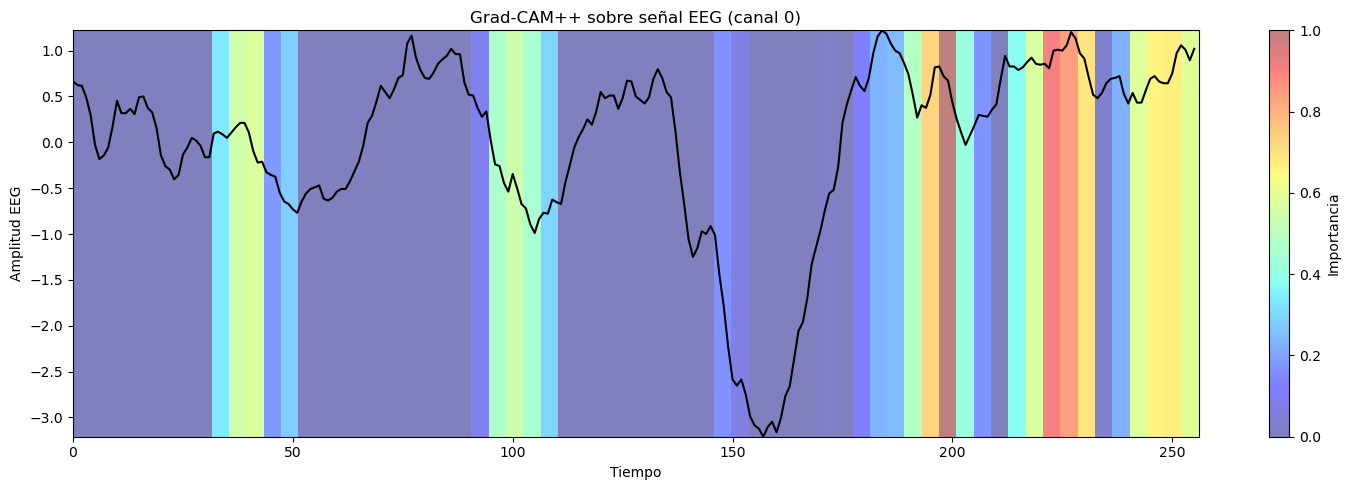

In [33]:
class GradCAMPlusPlus1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Hooks
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, class_idx=None):

        self.model.eval()

        # Forward
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward
        self.model.zero_grad()

        target = output[:, class_idx]
        target.backward(retain_graph=True)

        activations = self.activations.detach()
        gradients = self.gradients.detach()

        # ======================================
        # Grad-CAM++
        # ======================================

        gradients_power_2 = gradients ** 2
        gradients_power_3 = gradients ** 3

        sum_activations = torch.sum(activations, dim=2, keepdim=True)

        eps = 1e-8

        alpha_denom = (
            2 * gradients_power_2
            + sum_activations * gradients_power_3
        )

        alpha_denom = torch.where(
            alpha_denom != 0.0,
            alpha_denom,
            torch.ones_like(alpha_denom) * eps
        )

        alphas = gradients_power_2 / alpha_denom

        positive_gradients = F.relu(gradients)

        weights = torch.sum(alphas * positive_gradients, dim=2)

        # Corregimos la forma para que tenga la misma dimensión espacial que las activaciones
        weights = weights.unsqueeze(2)

        cam = torch.sum(weights * activations, dim=1)

        # ReLU
        cam = F.relu(cam)

        # Normalización
        cam = cam - cam.min()

        if cam.max() != 0:
            cam = cam / cam.max()

        cam = cam.squeeze().cpu().numpy()

        return cam

# Última capa convolucional

target_layer = model.separable_depth

# Crear objeto Grad-CAM++
gradcam_pp = GradCAMPlusPlus1D(model, target_layer)

# Seleccionar una muestra
sample_signal = signals[0:1].to(device)

# Generar mapa
cam_pp = gradcam_pp.generate_cam(sample_signal)

signal_plot = sample_signal.squeeze().cpu().numpy()

# Seleccionar primer canal si es multicanal
if signal_plot.ndim > 1:
    sig_plot = signal_plot[0]
else:
    sig_plot = signal_plot

plt.figure(figsize=(15, 5))

# Señal EEG (primer canal)
plt.plot(sig_plot, color='black', linewidth=1.5)

# Heatmap Grad-CAM++ sobre el primer canal
plt.imshow(
    np.expand_dims(cam_pp, axis=0),
    aspect='auto',
    cmap='jet',
    alpha=0.5,
    extent=[0, len(sig_plot), sig_plot.min(), sig_plot.max()]
)

plt.colorbar(label='Importancia')

plt.title('Grad-CAM++ sobre señal EEG (canal 0)')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud EEG')

plt.tight_layout()
plt.show()

Muestra con crisis epiléptica encontrada - Label: 1.0


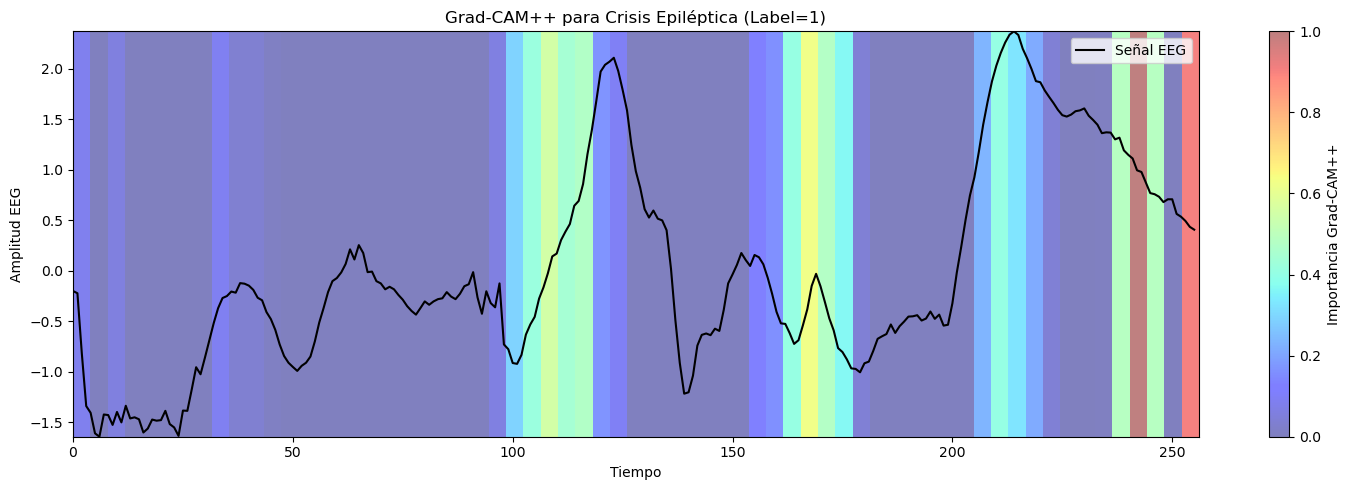

In [34]:
# ========================================
# Grad-CAM++ para CRISIS EPILÉPTICA (label=1)
# ========================================

# Buscar una muestra con label=1 en el test_loader
seizure_found = False
for batch_signals, batch_labels in test_loader:
    for idx in range(len(batch_labels)):
        if batch_labels[idx].item() == 1:
            seizure_signal = batch_signals[idx:idx+1].to(device)
            seizure_label = batch_labels[idx:idx+1]
            seizure_found = True
            break
    if seizure_found:
        break

if seizure_found:
    print(f"Muestra con crisis epiléptica encontrada - Label: {seizure_label.item()}")
    
    # Generar Grad-CAM++ para la muestra de crisis
    cam_pp_seizure = gradcam_pp.generate_cam(seizure_signal)
    
    signal_plot_seizure = seizure_signal.squeeze().cpu().numpy()
    
    # Seleccionar primer canal si es multicanal
    if signal_plot_seizure.ndim > 1:
        sig_plot_seizure = signal_plot_seizure[0]
    else:
        sig_plot_seizure = signal_plot_seizure
    
    plt.figure(figsize=(15, 5))
    
    # Señal EEG (primer canal) con crisis
    plt.plot(sig_plot_seizure, color='black', linewidth=1.5, label='Señal EEG')
    
    # Heatmap Grad-CAM++ sobre el primer canal
    plt.imshow(
        np.expand_dims(cam_pp_seizure, axis=0),
        aspect='auto',
        cmap='jet',
        alpha=0.5,
        extent=[0, len(sig_plot_seizure), sig_plot_seizure.min(), sig_plot_seizure.max()]
    )
    
    plt.colorbar(label='Importancia Grad-CAM++')
    
    plt.title('Grad-CAM++ para Crisis Epiléptica (Label=1)')
    plt.xlabel('Tiempo')
    plt.ylabel('Amplitud EEG')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró ninguna muestra con label=1 en el test_loader")